Olist wants to identify which customers generate the highest long-term value.

Understanding customer lifetime value helps the business prioritize retention efforts, allocate marketing budgets effectively, and improve customer profitability.

1. Which customers generate the most revenue?

2. What is the average customer lifetime value?

3. How much revenue comes from the top customers?

4. How does CLV vary across customer segments?

5. Which customers should be prioritized for retention campaigns?

## Why CLV Matters
Think of CLV as answering two separate questions:
How long did the customer stay active?
How much did the customer spend during that time?

Customer Lifetime Value (CLV) estimates the total value a customer generates during their relationship with the business.

CLV helps organizations:

- Identify high-value customers
- Optimize marketing investments
- Improve customer retention
- Personalize campaigns
- Increase long-term profitability

In [2]:
# Create a visualization to make the pattern easier to interpret.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from pathlib import Path


In [3]:
DATA_DIR = Path("../data")

orders_df = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv")
customers_df = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv")
payments_df = pd.read_csv(DATA_DIR / "olist_order_payments_dataset.csv")

In [5]:
customers_df.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [7]:
payments_df.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [6]:
orders_df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

## Missing Value Assessment

The `orders_df` dataset contains missing values in delivery-related timestamp columns.

These fields are not required for Customer Lifetime Value (CLV) analysis because CLV focuses on:

- Customer identifiers
- Order identifiers
- Purchase dates
- Revenue

Therefore, no missing value treatment is required for this step.

In [8]:
# Convert purchase timestamp to datetime
orders_df["order_purchase_timestamp"] = pd.to_datetime(
    orders_df["order_purchase_timestamp"]
)

# Keep only completed orders
delivered_orders_df = orders_df[
    orders_df["order_status"] == "delivered"
].copy()

### Business Question

How can we combine customer, order, and payment data to calculate customer lifetime value?

### Why This Step Matters

Customer information, purchase history, and revenue data are stored in separate tables.

To calculate CLV, we need a single dataset containing:

- Customer identifier
- Order identifier
- Purchase date
- Revenue

### Important Consideration

We will use `customer_unique_id` instead of `customer_id`.

A single customer can have multiple `customer_id` values in the Olist dataset.

Using `customer_unique_id` ensures all purchases from the same customer are aggregated correctly.

In [9]:
# Merge customer information with delivered orders
customer_orders_df = customers_df.merge(
    delivered_orders_df,
    on="customer_id",
    how="inner"
)

In [10]:
customer_orders_df.shape

(96478, 12)

In [11]:
# Add payment information to customer orders
customer_transactions_df = customer_orders_df.merge(
    payments_df,
    on="order_id",
    how="inner"
)

In [12]:
customer_transactions_df.shape

(100756, 16)

### Business Question

How much revenue did each order generate?

### Why This Step Matters

An order can have multiple payment records because customers may use multiple payment methods.

To avoid double-counting revenue, we must aggregate payments at the order level before calculating customer value.

In [13]:
# Calculate total payment value for each order
order_payments_df = (
    payments_df
    .groupby("order_id", as_index=False)
    .agg(
        total_payment_value=("payment_value", "sum")
    )
)

In [14]:
order_payments_df.head()

,order_id,total_payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [15]:
order_payments_df.shape

(99440, 2)

In [16]:
# Merge customer and order information
customer_orders_df = customers_df.merge(
    delivered_orders_df,
    on="customer_id",
    how="inner"
)

# Merge aggregated order revenue
customer_transactions_df = customer_orders_df.merge(
    order_payments_df,
    on="order_id",
    how="inner"
)

### Business Question

What are the purchasing behaviors and revenue contributions of each customer?

### Why This Step Matters

Customer Lifetime Value is calculated using customer-level metrics.

We need to understand:

- How many orders each customer placed
- How much revenue each customer generated
- How frequently customers purchase
- How long customers remain active

In [17]:
# Aggregate order and revenue information at the customer level
clv_df = (
    customer_transactions_df
    .groupby("customer_unique_id")
    .agg(
        first_purchase_date=(
            "order_purchase_timestamp",
            "min"
        ),
        last_purchase_date=(
            "order_purchase_timestamp",
            "max"
        ),
        total_orders=(
            "order_id",
            "nunique"
        ),
        total_revenue=(
            "total_payment_value",
            "sum"
        )
    )
    .reset_index()
)

Customer lifespan measures the number of days between a customer's first and last purchase.

This metric helps estimate how long customers remain active.

In [20]:
# Calculate customer lifespan in days
clv_df["customer_lifespan_days"] = (
    clv_df["last_purchase_date"]
    - clv_df["first_purchase_date"]
).dt.days

In [18]:
# Calculate average revenue per order
clv_df["average_order_value"] = (
    clv_df["total_revenue"]
    / clv_df["total_orders"]
)

In [21]:
clv_df[
    [
        "customer_unique_id",
        "total_orders",
        "total_revenue",
        "customer_lifespan_days",
        "average_order_value"
    ]
].head()

,customer_unique_id,total_orders,total_revenue,customer_lifespan_days,average_order_value
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,0,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,0,27.19
2,0000f46a3911fa3c0805444483337064,1,86.22,0,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,0,43.62
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,0,196.89


### Business Question

How frequently do customers make purchases?

### Why This Step Matters

Purchase frequency measures how often customers place orders.

Customers who purchase more frequently tend to generate higher lifetime value and are more likely to respond to retention campaigns.

Customers with a single purchase have a lifespan of zero days.

To avoid division-by-zero errors, we replace zero values with one day before calculating purchase frequency.

In [22]:
# Replace zero lifespan values to avoid division by zero
clv_df["customer_lifespan_days"] = (
    clv_df["customer_lifespan_days"]
    .replace(0, 1)
)

# Calculate purchase frequency
clv_df["purchase_frequency"] = (
    clv_df["total_orders"]
    / clv_df["customer_lifespan_days"]
)

### Business Question

What is the total lifetime value of each customer?

formula CLV=Average Order Value×Purchase Frequency×Customer Lifespan (Days)

In [23]:
# Calculate historical customer lifetime value
clv_df["historical_clv"] = clv_df["total_revenue"]

In [24]:
clv_df["historical_clv"].describe()

count    93357.000000
mean       165.198772
std        226.314579
min          9.590000
25%         63.060000
50%        107.780000
75%        182.560000
max      13664.080000
Name: historical_clv, dtype: float64

## Key Findings

- The average customer lifetime value is $165.20.
- The median customer lifetime value is $107.78.
- Customer value is highly right-skewed, indicating that a small group of customers contributes disproportionately to revenue.
- Seventy-five percent of customers generate less than $182.56 in lifetime revenue.
- The highest-value customer generated more than $13,000 in revenue.

In [25]:
top_customers_df = (
    clv_df
    .sort_values(
        by="historical_clv",
        ascending=False
    )
    .head(10)
)

top_customers_df

,customer_unique_id,first_purchase_date,last_purchase_date,total_orders,total_revenue,average_order_value,customer_lifespan_days,purchase_frequency,historical_clv
3724,0a0a92112bd4c708ca5fde585afaa872,2017-09-29 15:24:52,2017-09-29 15:24:52,1,13664.08,13664.0800,1,1.0,13664.08
79635,da122df9eeddfedc1dc1f5349a1a690c,2017-04-01 15:58:40,2017-04-01 15:58:41,2,7571.63,3785.8150,1,2.0,7571.63
43168,763c8b1c9c68a0229c42c9fc6f662b93,2018-07-15 14:49:44,2018-07-15 14:49:44,1,7274.88,7274.8800,1,1.0,7274.88
80462,dc4802a71eae9be1dd28f5d788ceb526,2017-02-12 20:37:36,2017-02-12 20:37:36,1,6929.31,6929.3100,1,1.0,6929.31
25436,459bef486812aa25204be022145caa62,2018-07-25 18:10:17,2018-07-25 18:10:17,1,6922.21,6922.2100,1,1.0,6922.21
93080,ff4159b92c40ebe40454e3e6a7c35ed6,2017-05-24 18:14:34,2017-05-24 18:14:34,1,6726.66,6726.6600,1,1.0,6726.66
23411,4007669dec559734d6f53e029e360987,2017-11-24 11:03:35,2017-11-24 11:03:35,1,6081.54,6081.5400,1,1.0,6081.54
87147,eebb5dda148d3893cdaf5b5ca3040ccb,2017-04-18 18:50:13,2017-04-18 18:50:13,1,4764.34,4764.3400,1,1.0,4764.34
26640,48e1ac109decbb87765a3eade6854098,2018-06-22 12:23:19,2018-06-22 12:23:19,1,4681.78,4681.7800,1,1.0,4681.78
73126,c8460e4251689ba205045f3ea17884a1,2018-08-07 09:03:02,2018-08-08 14:27:15,4,4655.91,1163.9775,1,4.0,4655.91


## Key Findings

The highest-value customers in Olist are primarily driven by large transaction amounts rather than frequent purchases.

Most top customers placed only one order but generated substantial revenue.

This suggests that customer lifetime value in Olist is influenced more by order size than customer retention.

Identifying and retaining customers with both high revenue and repeat purchases may offer the greatest long-term business value.

Customers with a lifespan of zero days were assigned a value of one day to avoid division-by-zero errors when calculating purchase frequency.

A lifespan value of one day does not necessarily indicate customer retention beyond a single transaction.

In [26]:
clv_df["clv_segment"] = pd.qcut(
    clv_df["historical_clv"],
    q=4,
    labels=[
        "Low Value",
        "Mid Value",
        "High Value",
        "VIP"
    ]
)

In [27]:
clv_df["clv_segment"].value_counts()

clv_segment
Low Value     23341
Mid Value     23339
VIP           23339
High Value    23338
Name: count, dtype: int64

In [28]:
# how value is each segement 
clv_summary_df = (
    clv_df
    .groupby("clv_segment", observed=False)
    .agg(
        customer_count=("customer_unique_id", "count"),
        average_clv=("historical_clv", "mean"),
        median_clv=("historical_clv", "median"),
        average_orders=("total_orders", "mean")
    )
    .round(2)
)

clv_summary_df

,customer_count,average_clv,median_clv,average_orders
clv_segment,,,,
Low Value,23341,43.60,44.01,1.00
Mid Value,23339,83.56,82.88,1.01
High Value,23338,140.98,138.89,1.03
VIP,23339,392.68,276.72,1.09


## Segment Insights

Customer Lifetime Value increases substantially across customer segments.

However, average order frequency remains close to one order across all segments.

This indicates that higher customer value is driven primarily by larger transaction amounts rather than repeat purchases.

VIP customers generate significantly more revenue than other segments, although their spending distribution is highly skewed due to a small number of extremely high-value customers.

## Recommendations

- Prioritize retention efforts for VIP customers.
- Develop personalized promotions for high-value customers.
- Encourage repeat purchases through loyalty programs.
- Increase average order value using product bundles and targeted recommendations.
- Identify opportunities to convert Mid Value customers into High Value customers.

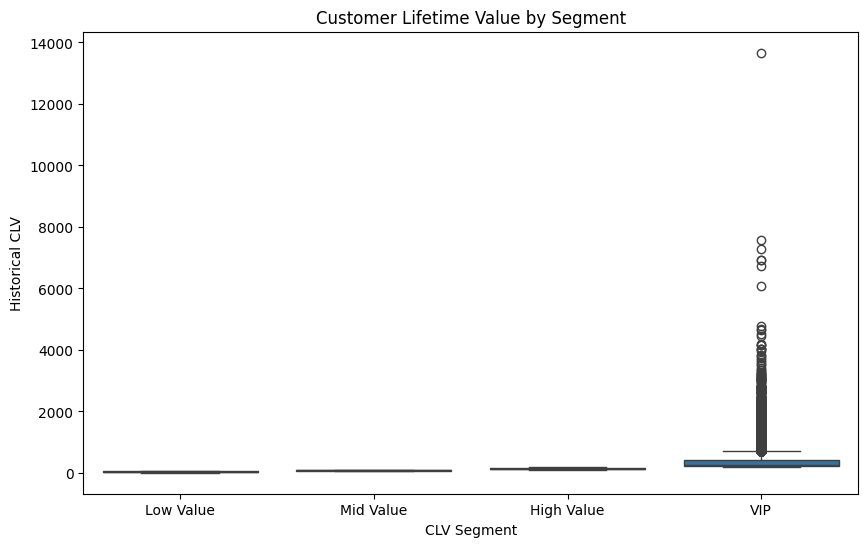

In [29]:
# visualize Clv distribution 
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=clv_df,
    x="clv_segment",
    y="historical_clv"
)

plt.title("Customer Lifetime Value by Segment")
plt.xlabel("CLV Segment")
plt.ylabel("Historical CLV")

plt.show()

## CLV Distribution by Segment

The boxplot shows a clear increase in customer lifetime value across segments.

The VIP segment contains a large number of high-value outliers, indicating that a small group of customers contributes disproportionately to total revenue.

The difference between the average and median CLV within the VIP segment suggests a highly right-skewed distribution.

Lower-value segments exhibit more consistent spending behavior with fewer extreme values.

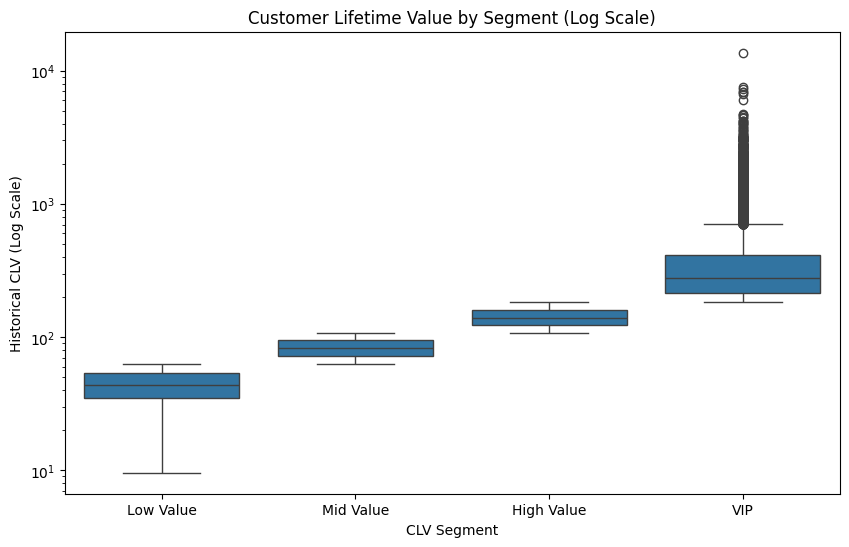

In [30]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=clv_df,
    x="clv_segment",
    y="historical_clv"
)

plt.yscale("log")

plt.title("Customer Lifetime Value by Segment (Log Scale)")
plt.xlabel("CLV Segment")
plt.ylabel("Historical CLV (Log Scale)")

plt.show()

## Key Findings

- The average customer lifetime value is $165.20.
- The median customer lifetime value is $107.78.
- Customer lifetime value is highly right-skewed.
- A small group of customers contributes disproportionately to total revenue.
- VIP customers have an average CLV of $392.68.
- Average order frequency remains close to one order across all segments.
- Higher CLV is driven primarily by larger transaction amounts rather than repeat purchases.